In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Annotated

In [7]:
class ChatState(BaseModel):
    messages: Annotated[list,add_messages] = []

In [8]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [9]:
def chatBot(state:ChatState)->ChatState:
  res= llm.invoke(state.messages)
  state.messages = [res]
  return state

In [10]:
memory = InMemorySaver()

In [11]:
graph = StateGraph(ChatState)
graph.add_node('chatbot', chatBot)
graph.add_edge(START, 'chatbot')
graph.add_edge('chatbot', END)
graph = graph.compile(checkpointer=memory)

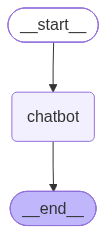

In [12]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())


In [16]:
config = {"configurable":{"thread_id":"my-bot-1"}}
res= graph.invoke({"messages":[{"role":"user","content":"what is my name"}]}, config=config)

In [17]:
res["messages"][-1].content

'Your name is Yash.'